# EDA 10.1: Return Rate by Category and Size

This notebook analyzes return rate by product category and size, return and refund trends over time, and the observed effect of returns on net revenue. Findings are exploratory signals for quality control, product risk, and forecast feature engineering, not causal claims.

## 1. Setup and File Discovery

Locate required and optional CSV files anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 220)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['returns.csv', 'order_items.csv', 'products.csv', 'sales.csv', 'orders.csv', 'payments.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in ['returns.csv', 'order_items.csv', 'products.csv', 'sales.csv'], 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in ['returns.csv', 'order_items.csv', 'products.csv', 'sales.csv']:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,returns.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
1,order_items.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
2,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
3,sales.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
4,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
5,payments.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...


## 2. Load Returns, Order Items, Products, Sales, and Optional Files

Load all available CSVs safely with pandas and display the raw schemas.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

raw = {name: safe_read_csv(path, name) for name, path in selected_paths.items()}
returns_raw = raw.get('returns.csv')
order_items_raw = raw.get('order_items.csv')
products_raw = raw.get('products.csv')
sales_raw = raw.get('sales.csv')
orders_raw = raw.get('orders.csv')
payments_raw = raw.get('payments.csv')

schema_rows = []
for name, df in raw.items():
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded returns.csv: 39,939 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\returns.csv


Loaded order_items.csv: 714,669 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\order_items.csv
Loaded products.csv: 2,412 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\products.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


Loaded orders.csv: 646,945 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\orders.csv


Loaded payments.csv: 646,945 rows x 4 columns from D:\Code\Datathon 2026\datathon-2026-round-1\payments.csv


,file,rows,columns,column_names
0,returns.csv,39939,7,"return_id, order_id, product_id, return_date, ..."
1,order_items.csv,714669,7,"order_id, product_id, quantity, unit_price, di..."
2,products.csv,2412,8,"product_id, product_name, category, segment, s..."
3,sales.csv,3833,3,"Date, Revenue, COGS"
4,orders.csv,646945,8,"order_id, order_date, customer_id, zip, order_..."
5,payments.csv,646945,4,"order_id, payment_method, payment_value, insta..."


## 3. Identify Return, Order, Product, Category, Size, Quantity, Refund, Date, and Revenue Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def infer_revenue_col(df):
    if df is None:
        return None
    direct = find_col(
        df,
        ['revenue', 'gross_revenue', 'total_revenue', 'sales_amount', 'sales', 'net_sales', 'amount'],
        include_any=['revenue', 'grossrevenue', 'salesamount', 'totalsales', 'netsales'],
        exclude_any=['cost', 'cogs', 'margin', 'profit', 'tax'],
        prefer_numeric=True,
    )
    if direct is not None:
        return direct
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or to_num(df[c]).notna().mean() > 0.8]
    candidates = []
    for c in numeric_cols:
        key = normalize_name(c)
        if any(x in key for x in ['cost', 'cogs', 'margin', 'profit', 'tax', 'id']):
            continue
        vals = to_num(df[c])
        candidates.append(((vals > 0).mean(), vals.abs().sum(skipna=True), c))
    if candidates:
        candidates.sort(key=lambda x: (-x[0], -x[1], str(x[2])))
        warnings.warn(f'Revenue column was not explicit; using likely numeric revenue column: {candidates[0][2]}')
        return candidates[0][2]
    return None

cols = {}
if returns_raw is not None:
    cols['return_id'] = find_col(returns_raw, ['return_id', 'returnid', 'rma_id'], include_any=['returnid', 'rmaid'])
    cols['ret_order_id'] = find_col(returns_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['ret_product_id'] = find_col(returns_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['ret_customer_id'] = find_col(returns_raw, ['customer_id', 'customerid'], include_all=['customer', 'id'])
    cols['return_date'] = find_col(returns_raw, ['return_date', 'date', 'refund_date'], include_any=['returndate', 'refunddate', 'date'])
    cols['return_qty'] = find_col(returns_raw, ['return_quantity', 'returned_quantity', 'quantity_returned', 'quantity', 'qty'], include_any=['returnquantity', 'returnedquantity', 'quantityreturned', 'quantity', 'qty'], prefer_numeric=True)
    cols['refund_amount'] = find_col(returns_raw, ['refund_amount', 'refund_value', 'refund', 'amount'], include_any=['refundamount', 'refundvalue', 'refund'], exclude_any=['id'], prefer_numeric=True)
if order_items_raw is not None:
    cols['oi_order_id'] = find_col(order_items_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['oi_product_id'] = find_col(order_items_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['oi_qty'] = find_col(order_items_raw, ['quantity', 'qty', 'units_sold'], include_any=['quantity', 'qty', 'unitssold'], prefer_numeric=True)
    cols['oi_unit_price'] = find_col(order_items_raw, ['unit_price', 'selling_price', 'price'], include_any=['unitprice', 'sellingprice', 'price'], exclude_any=['discount', 'cost'], prefer_numeric=True)
    cols['oi_discount'] = find_col(order_items_raw, ['discount_amount', 'discount_value', 'discount'], include_any=['discountamount', 'discountvalue', 'discount'], exclude_any=['id'], prefer_numeric=True)
    cols['oi_date'] = find_col(order_items_raw, ['order_date', 'date', 'item_date'], include_any=['date'])
if products_raw is not None:
    cols['prod_product_id'] = find_col(products_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['prod_category'] = find_col(products_raw, ['category', 'product_category'], include_any=['category'])
    cols['prod_size'] = find_col(products_raw, ['size', 'product_size'], include_any=['size'])
if orders_raw is not None:
    cols['orders_order_id'] = find_col(orders_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['orders_date'] = find_col(orders_raw, ['order_date', 'date'], include_any=['orderdate', 'date'])
if sales_raw is not None:
    cols['sales_date'] = find_col(sales_raw, ['date', 'sales_date', 'order_date'], include_any=['date'])
    cols['sales_revenue'] = infer_revenue_col(sales_raw)

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)

,role,column
0,return_id,return_id
1,ret_order_id,order_id
2,ret_product_id,product_id
3,ret_customer_id,None
4,return_date,return_date
5,return_qty,return_quantity
6,refund_amount,refund_amount
7,oi_order_id,order_id
8,oi_product_id,product_id
9,oi_qty,quantity


## 4. Return Data Quality Checks

Inspect return date coverage, missing keys, missing quantities/refunds, and duplicate return records.

In [4]:
returns_df = pd.DataFrame()
return_warnings = []

if returns_raw is None or returns_raw.empty:
    return_warnings.append('returns.csv is missing or empty.')
else:
    returns_df = returns_raw.copy()
    if cols.get('return_date'):
        returns_df['return_date_std'] = pd.to_datetime(returns_df[cols['return_date']], errors='coerce').dt.floor('D')
    else:
        returns_df['return_date_std'] = pd.NaT
        return_warnings.append('Return date column could not be identified.')
    if cols.get('ret_order_id'):
        returns_df['order_id_std'] = returns_df[cols['ret_order_id']].astype('string').str.strip()
    else:
        returns_df['order_id_std'] = pd.NA
        return_warnings.append('Return order ID could not be identified.')
    if cols.get('ret_product_id'):
        returns_df['product_id_std'] = returns_df[cols['ret_product_id']].astype('string').str.strip()
    else:
        returns_df['product_id_std'] = pd.NA
        return_warnings.append('Return product ID could not be identified.')
    returns_df['returned_quantity_std'] = to_num(returns_df[cols['return_qty']]) if cols.get('return_qty') else np.nan
    returns_df['refund_amount_std'] = to_num(returns_df[cols['refund_amount']]) if cols.get('refund_amount') else np.nan
    duplicate_keys = ['order_id_std', 'product_id_std', 'return_date_std']
    report = pd.DataFrame([
        {'metric': 'return_rows', 'value': len(returns_df)},
        {'metric': 'return_date_range_start', 'value': returns_df['return_date_std'].min()},
        {'metric': 'return_date_range_end', 'value': returns_df['return_date_std'].max()},
        {'metric': 'missing_return_dates', 'value': int(returns_df['return_date_std'].isna().sum())},
        {'metric': 'missing_order_ids', 'value': int(returns_df['order_id_std'].isna().sum())},
        {'metric': 'missing_product_ids', 'value': int(returns_df['product_id_std'].isna().sum())},
        {'metric': 'missing_return_quantities', 'value': int(returns_df['returned_quantity_std'].isna().sum())},
        {'metric': 'missing_refund_amounts', 'value': int(returns_df['refund_amount_std'].isna().sum())},
        {'metric': 'duplicate_return_records', 'value': int(returns_df.duplicated(duplicate_keys).sum())},
    ])
    display(report)
    display(returns_df.head())
    display(returns_df[['returned_quantity_std', 'refund_amount_std']].describe().T)

if return_warnings:
    print('Return warnings:')
    for w in return_warnings:
        print('-', w)

,metric,value
0,return_rows,39939
1,return_date_range_start,2012-07-11 00:00:00
2,return_date_range_end,2022-12-31 00:00:00
3,missing_return_dates,0
4,missing_order_ids,0
5,missing_product_ids,0
6,missing_return_quantities,0
7,missing_refund_amounts,0
8,duplicate_return_records,0


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,return_date_std,order_id_std,product_id_std,returned_quantity_std,refund_amount_std
0,RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.0100",2012-07-25,2,609,6,"52,458.0100"
1,RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.3700",2012-07-16,32,1862,2,"5,141.3700"
2,RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.9500",2012-07-16,35,2359,1,"5,315.9500"
3,RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.7500",2012-07-11,47,1449,4,"6,493.7500"
4,RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.7600",2012-07-25,47,1450,1,"1,740.7600"


,count,mean,std,min,25%,50%,75%,max
returned_quantity_std,"39,939.0000",2.7438,1.8283,1.0000,1.0000,2.0000,4.0000,8.0000
refund_amount_std,"39,939.0000","12,784.4590","14,092.1502",458.8100,"3,573.3950","7,888.8800","16,881.9900","160,937.9400"


## 5. Build Return-Enriched Item Dataset

Start from order items, join products for category and size, join returns using the best available keys, and join orders if needed to obtain order date.

In [5]:
items = pd.DataFrame()
returns_join_quality = pd.DataFrame()
matching_mode = 'unavailable'

if order_items_raw is None or order_items_raw.empty:
    print('order_items.csv is unavailable; return-enriched item dataset cannot be built.')
else:
    items = order_items_raw.copy()
    items['_row_id'] = np.arange(len(items))
    items['order_id_std'] = items[cols['oi_order_id']].astype('string').str.strip() if cols.get('oi_order_id') else pd.NA
    items['product_id_std'] = items[cols['oi_product_id']].astype('string').str.strip() if cols.get('oi_product_id') else pd.NA
    items['ordered_quantity'] = to_num(items[cols['oi_qty']]) if cols.get('oi_qty') else np.nan
    items['unit_price_std'] = to_num(items[cols['oi_unit_price']]) if cols.get('oi_unit_price') else np.nan
    items['discount_std'] = to_num(items[cols['oi_discount']]) if cols.get('oi_discount') else 0
    items['item_revenue'] = items['unit_price_std'] * items['ordered_quantity']

    if cols.get('oi_date'):
        items['order_date_std'] = pd.to_datetime(items[cols['oi_date']], errors='coerce').dt.floor('D')
    elif orders_raw is not None and cols.get('orders_order_id') and cols.get('orders_date') and cols.get('oi_order_id'):
        od = orders_raw[[cols['orders_order_id'], cols['orders_date']]].drop_duplicates(cols['orders_order_id']).copy()
        od['order_date_std'] = pd.to_datetime(od[cols['orders_date']], errors='coerce').dt.floor('D')
        items = items.merge(od[[cols['orders_order_id'], 'order_date_std']], left_on=cols['oi_order_id'], right_on=cols['orders_order_id'], how='left')
    else:
        items['order_date_std'] = pd.NaT

    # Join products
    if products_raw is not None and cols.get('prod_product_id'):
        prod = products_raw.copy()
        prod['product_id_std'] = prod[cols['prod_product_id']].astype('string').str.strip()
        prod_keep = ['product_id_std']
        for c in [cols.get('prod_category'), cols.get('prod_size')]:
            if c and c not in prod_keep:
                prod_keep.append(c)
        prod = prod[prod_keep].drop_duplicates('product_id_std')
        product_set = set(prod['product_id_std'].dropna())
        product_match = int(items['product_id_std'].isin(product_set).sum())
        items = items.merge(prod, on='product_id_std', how='left', suffixes=('', '_prod'))
    else:
        product_match = np.nan

    if cols.get('prod_category') and cols.get('prod_category') in items.columns:
        items['category_final'] = items[cols['prod_category']].astype('string').fillna('Unknown')
    else:
        items['category_final'] = 'Unknown'
        return_warnings.append('Category could not be identified from products.csv; category-level return analysis may be limited.')
    if cols.get('prod_size') and cols.get('prod_size') in items.columns:
        items['size_final'] = items[cols['prod_size']].astype('string').fillna('Unknown')
    else:
        items['size_final'] = pd.NA
        return_warnings.append('Size could not be identified from products.csv; return-rate-by-size analysis cannot be fully performed.')

    # Join returns, preferring exact order_id + product_id.
    if not returns_df.empty and returns_df['order_id_std'].notna().any() and returns_df['product_id_std'].notna().any():
        ret_key = returns_df.groupby(['order_id_std', 'product_id_std'], as_index=False).agg(
            returned_quantity=('returned_quantity_std', 'sum'),
            refund_amount=('refund_amount_std', 'sum'),
            first_return_date=('return_date_std', 'min'),
            return_count=('return_date_std', 'count'),
        )
        items = items.merge(ret_key, on=['order_id_std', 'product_id_std'], how='left')
        matching_mode = 'exact order_id + product_id'
        matched_returns = int(ret_key[['returned_quantity', 'refund_amount', 'first_return_date']].notna().any(axis=1).sum())
        unmatched_returns = int(len(returns_df.groupby(['order_id_std', 'product_id_std'])) - ret_key[['returned_quantity', 'refund_amount', 'first_return_date']].notna().any(axis=1).sum())
        returns_unmatched_sample = pd.DataFrame()
    elif not returns_df.empty and returns_df['order_id_std'].notna().any():
        ret_key = returns_df.groupby('order_id_std', as_index=False).agg(
            returned_quantity=('returned_quantity_std', 'sum'),
            refund_amount=('refund_amount_std', 'sum'),
            first_return_date=('return_date_std', 'min'),
            return_count=('return_date_std', 'count'),
        )
        items = items.merge(ret_key, on='order_id_std', how='left')
        matching_mode = 'approximate order_id only'
        matched_returns = int(ret_key[['returned_quantity', 'refund_amount', 'first_return_date']].notna().any(axis=1).sum())
        unmatched_returns = 0
        returns_unmatched_sample = pd.DataFrame()
        return_warnings.append('Returns were matched approximately using order_id only because product-level matching was unavailable.')
    else:
        items['returned_quantity'] = np.nan
        items['refund_amount'] = np.nan
        items['first_return_date'] = pd.NaT
        items['return_count'] = np.nan
        matched_returns = np.nan
        unmatched_returns = np.nan
        returns_unmatched_sample = pd.DataFrame()
        return_warnings.append('Returns could not be matched to order items because return keys were unavailable.')

    if 'returned_quantity' not in items.columns:
        items['returned_quantity'] = 0
    items['returned_quantity'] = items['returned_quantity'].fillna(0)
    if 'refund_amount' not in items.columns:
        items['refund_amount'] = np.nan
    items['return_indicator'] = items['returned_quantity'].fillna(0) > 0

    exact_return_keys = set(zip(items['order_id_std'], items['product_id_std']))
    raw_return_keys = set(zip(returns_df['order_id_std'], returns_df['product_id_std'])) if not returns_df.empty else set()
    unmatched_key_rows = sorted(raw_return_keys - exact_return_keys)[:20]
    returns_unmatched_sample = pd.DataFrame(unmatched_key_rows, columns=['order_id_std', 'product_id_std']) if unmatched_key_rows else pd.DataFrame()

    returns_join_quality = pd.DataFrame([
        {'metric': 'order_items_matched_to_products', 'value': product_match},
        {'metric': 'order_items_unmatched_to_products', 'value': int(len(items) - product_match) if pd.notna(product_match) else np.nan},
        {'metric': 'returns_matching_mode', 'value': matching_mode},
        {'metric': 'returns_unmatched_to_order_items', 'value': len(returns_unmatched_sample)},
    ])
    display(returns_join_quality)
    if not returns_unmatched_sample.empty:
        print('Sample unmatched returns:')
        display(returns_unmatched_sample)
    display(items.head())

,metric,value
0,order_items_matched_to_products,714669
1,order_items_unmatched_to_products,0
2,returns_matching_mode,exact order_id + product_id
3,returns_unmatched_to_order_items,0


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,_row_id,order_id_std,product_id_std,ordered_quantity,unit_price_std,discount_std,item_revenue,order_date_std,category,size,category_final,size_final,returned_quantity,refund_amount,first_return_date,return_count,return_indicator
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN,0,1,2400,7,"1,138.2200",0.0000,"7,967.5400",2012-07-04,GenZ,S,GenZ,S,0.0000,NaN,NaT,NaN,False
1,2,609,7,"10,166.2500",0.0000,NaN,NaN,1,2,609,7,"10,166.2500",0.0000,"71,163.7500",2012-07-04,Streetwear,M,Streetwear,M,6.0000,"52,458.0100",2012-07-25,1.0000,True
2,3,396,3,"11,220.3300",0.0000,NaN,NaN,2,3,396,3,"11,220.3300",0.0000,"33,660.9900",2012-07-04,Streetwear,S,Streetwear,S,0.0000,NaN,NaT,NaN,False
3,4,635,5,"10,639.2500",0.0000,NaN,NaN,3,4,635,5,"10,639.2500",0.0000,"53,196.2500",2012-07-04,Streetwear,XL,Streetwear,XL,0.0000,NaN,NaT,NaN,False
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN,4,6,1935,1,"1,597.8400",0.0000,"1,597.8400",2012-07-06,Outdoor,XL,Outdoor,XL,0.0000,NaN,NaT,NaN,False


## 6. Define Return Metrics

Define the primary return-rate metric and supporting return, refund, and net-revenue measures.

In [6]:
primary_return_definition = ''
if items.empty:
    print('Return-enriched item data is unavailable; return metrics cannot be defined.')
else:
    if items['ordered_quantity'].notna().any() and items['returned_quantity'].notna().any():
        primary_return_definition = 'Primary return rate = returned_quantity / ordered_quantity.'
        items['return_rate_line'] = np.where(items['ordered_quantity'] > 0, items['returned_quantity'] / items['ordered_quantity'], np.nan)
    else:
        primary_return_definition = 'Primary return rate = returned item lines / ordered item lines because quantity fields were unavailable.'
        items['return_rate_line'] = items['return_indicator'].astype(float)

    items['refund_to_revenue_ratio'] = np.where(items['item_revenue'] > 0, items['refund_amount'].fillna(0) / items['item_revenue'], np.nan)
    items['net_item_revenue'] = items['item_revenue'] - items['refund_amount'].fillna(0)
    print('Return metric definition used:')
    print(primary_return_definition)
    display(items[['order_id_std', 'product_id_std', 'ordered_quantity', 'returned_quantity', 'return_indicator', 'refund_amount', 'item_revenue', 'net_item_revenue']].head(20))

Return metric definition used:
Primary return rate = returned_quantity / ordered_quantity.


,order_id_std,product_id_std,ordered_quantity,returned_quantity,return_indicator,refund_amount,item_revenue,net_item_revenue
0,1,2400,7,0.0000,False,NaN,"7,967.5400","7,967.5400"
1,2,609,7,6.0000,True,"52,458.0100","71,163.7500","18,705.7400"
2,3,396,3,0.0000,False,NaN,"33,660.9900","33,660.9900"
3,4,635,5,0.0000,False,NaN,"53,196.2500","53,196.2500"
4,6,1935,1,0.0000,False,NaN,"1,597.8400","1,597.8400"
5,7,1934,6,0.0000,False,NaN,"9,800.9400","9,800.9400"
6,8,1934,6,0.0000,False,NaN,"9,617.5200","9,617.5200"
7,8,1935,4,0.0000,False,NaN,"6,570.0400","6,570.0400"
8,9,1432,8,0.0000,False,NaN,"32,397.1200","32,397.1200"
9,10,1431,5,0.0000,False,NaN,"19,886.8500","19,886.8500"


## 7. Return Rate by Category

Aggregate ordered quantity, returned quantity, return rate, refunds, revenue, and net revenue by category.

,category_final,ordered_quantity,returned_quantity,order_item_lines,returned_lines,refund_amount,gross_revenue,net_revenue,return_rate,refund_to_revenue_ratio,small_sample_flag
1,GenZ,166848,"5,873.0000",37159,2126,"11,149,770.2400","343,599,095.3600","332,449,325.1200",0.0352,0.0324,False
2,Outdoor,1170000,"40,417.0000",259986,14720,"78,717,514.8800","2,494,882,754.2000","2,416,165,239.3200",0.0345,0.0316,False
3,Streetwear,1768826,"59,812.0000",393533,21799,"406,765,940.1000","13,131,346,352.6200","12,724,580,412.5200",0.0338,0.0310,False
0,Casual,107469,"3,499.0000",23991,1294,"14,027,094.3700","460,648,383.3500","446,621,288.9800",0.0326,0.0305,True


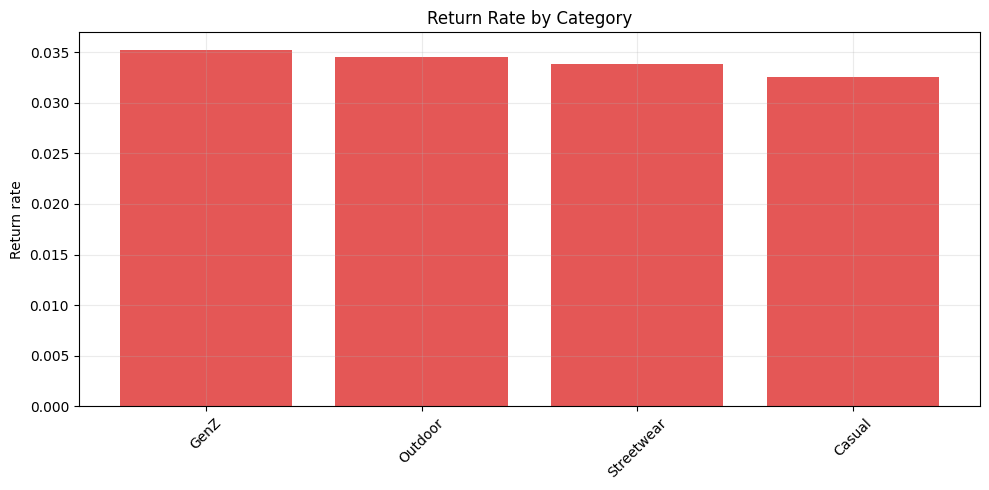

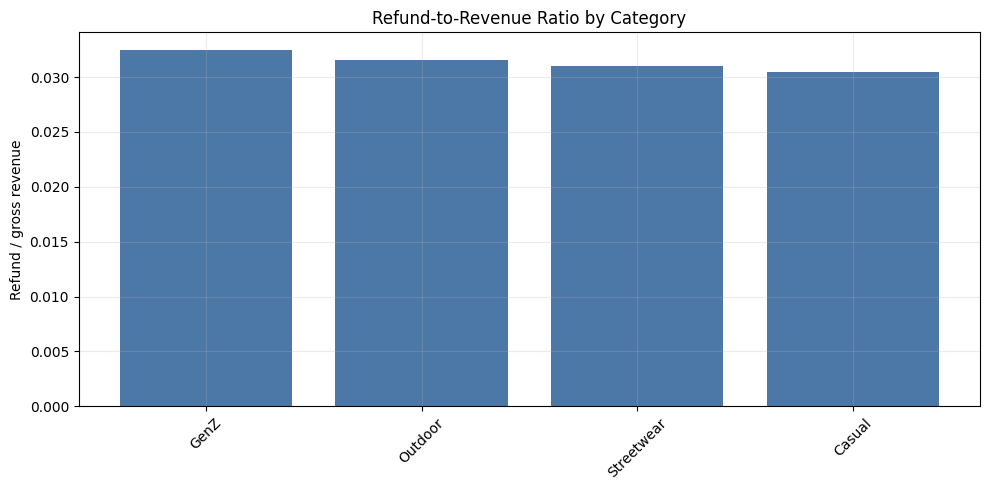

In [7]:
category_return = pd.DataFrame()
if items.empty or 'category_final' not in items.columns:
    print('Category return analysis cannot be computed.')
else:
    category_return = items.groupby('category_final').agg(
        ordered_quantity=('ordered_quantity', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        order_item_lines=('_row_id', 'count'),
        returned_lines=('return_indicator', 'sum'),
        refund_amount=('refund_amount', 'sum'),
        gross_revenue=('item_revenue', 'sum'),
        net_revenue=('net_item_revenue', 'sum'),
    ).reset_index()
    category_return['return_rate'] = np.where(category_return['ordered_quantity'] > 0, category_return['returned_quantity'] / category_return['ordered_quantity'], category_return['returned_lines'] / category_return['order_item_lines'].replace(0, np.nan))
    category_return['refund_to_revenue_ratio'] = np.where(category_return['gross_revenue'] > 0, category_return['refund_amount'] / category_return['gross_revenue'], np.nan)
    category_return['small_sample_flag'] = category_return['order_item_lines'] < max(20, category_return['order_item_lines'].quantile(0.1))
    category_return = category_return.sort_values('return_rate', ascending=False)
    display(category_return)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(category_return['category_final'].astype(str), category_return['return_rate'], color='#E45756')
    ax.set_title('Return Rate by Category')
    ax.set_ylabel('Return rate')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    if category_return['refund_to_revenue_ratio'].notna().any():
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(category_return['category_final'].astype(str), category_return['refund_to_revenue_ratio'], color='#4C78A8')
        ax.set_title('Refund-to-Revenue Ratio by Category')
        ax.set_ylabel('Refund / gross revenue')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

## 8. Return Rate by Size

Aggregate return metrics by product size when size is available.

,size_final,ordered_quantity,returned_quantity,returned_lines,order_item_lines,refund_amount,gross_revenue,net_revenue,return_rate,small_sample_flag
2,S,774468,"26,797.0000",9723,172042,"117,688,668.1000","3,748,377,382.1800","3,630,688,714.0800",0.0346,True
0,L,778599,"26,688.0000",9741,173174,"117,962,279.7300","3,824,056,755.1300","3,706,094,475.4000",0.0343,False
1,M,792889,"26,947.0000",9820,176428,"114,287,246.0900","3,659,144,479.1700","3,544,857,233.0800",0.0340,False
3,XL,867187,"29,169.0000",10655,193025,"160,722,125.6700","5,198,897,969.0500","5,038,175,843.3800",0.0336,False


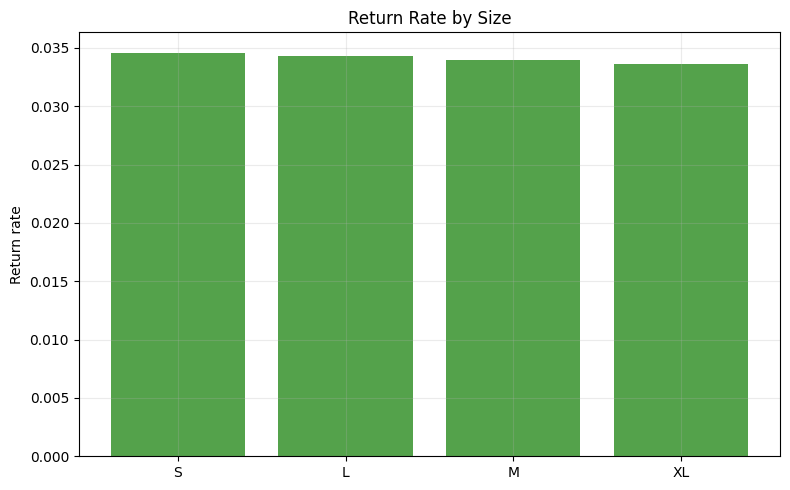

In [8]:
size_return = pd.DataFrame()
if items.empty or 'size_final' not in items.columns or items['size_final'].dropna().empty:
    print('Size data is unavailable; return-rate-by-size analysis is skipped.')
else:
    size_return = items.dropna(subset=['size_final']).groupby('size_final').agg(
        ordered_quantity=('ordered_quantity', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        returned_lines=('return_indicator', 'sum'),
        order_item_lines=('_row_id', 'count'),
        refund_amount=('refund_amount', 'sum'),
        gross_revenue=('item_revenue', 'sum'),
        net_revenue=('net_item_revenue', 'sum'),
    ).reset_index()
    size_return['return_rate'] = np.where(size_return['ordered_quantity'] > 0, size_return['returned_quantity'] / size_return['ordered_quantity'], size_return['returned_lines'] / size_return['order_item_lines'].replace(0, np.nan))
    size_return['small_sample_flag'] = size_return['order_item_lines'] < max(20, size_return['order_item_lines'].quantile(0.1))
    size_return = size_return.sort_values('return_rate', ascending=False)
    display(size_return)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(size_return['size_final'].astype(str), size_return['return_rate'], color='#54A24B')
    ax.set_title('Return Rate by Size')
    ax.set_ylabel('Return rate')
    plt.tight_layout()
    plt.show()

## 9. Return Rate by Category × Size

Display a category-by-size return-rate matrix using matplotlib when both category and size are available.

size_final,L,M,S,XL
category_final,,,,
Casual,0.0320,0.0327,0.0336,0.0309
GenZ,0.0314,0.0359,0.0361,0.0377
Outdoor,0.0352,0.0340,0.0355,0.0335
Streetwear,0.0339,0.0339,0.0339,0.0336


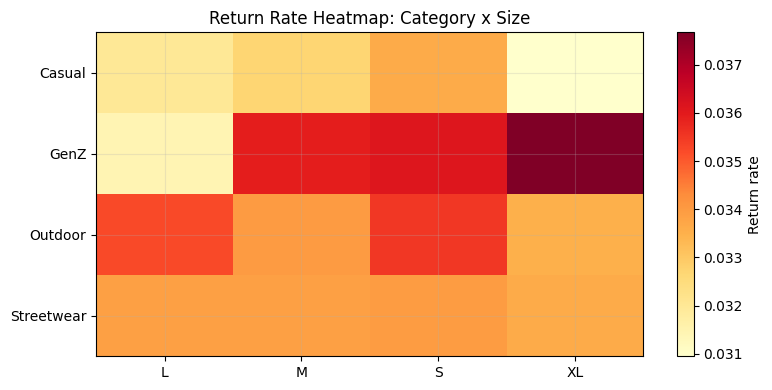

In [9]:
heatmap_matrix = pd.DataFrame()
if items.empty or 'category_final' not in items.columns or 'size_final' not in items.columns or items['size_final'].dropna().empty:
    print('Category-size return matrix cannot be computed because category or size data is unavailable.')
else:
    top_categories = category_return.head(8)['category_final'].tolist() if not category_return.empty else items['category_final'].value_counts().head(8).index.tolist()
    top_sizes = size_return.head(8)['size_final'].tolist() if not size_return.empty else items['size_final'].value_counts().head(8).index.tolist()
    temp = items[items['category_final'].isin(top_categories) & items['size_final'].isin(top_sizes)].copy()
    mat_rows = temp.groupby(['category_final', 'size_final']).agg(
        ordered_quantity=('ordered_quantity', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        returned_lines=('return_indicator', 'sum'),
        order_item_lines=('_row_id', 'count'),
    ).reset_index()
    mat_rows['return_rate'] = np.where(mat_rows['ordered_quantity'] > 0, mat_rows['returned_quantity'] / mat_rows['ordered_quantity'], mat_rows['returned_lines'] / mat_rows['order_item_lines'].replace(0, np.nan))
    heatmap_matrix = mat_rows.pivot(index='category_final', columns='size_final', values='return_rate').fillna(0)
    display(heatmap_matrix)

    fig, ax = plt.subplots(figsize=(max(8, heatmap_matrix.shape[1] * 0.8), max(4, heatmap_matrix.shape[0] * 0.5)))
    im = ax.imshow(heatmap_matrix.values, aspect='auto', cmap='YlOrRd')
    ax.set_title('Return Rate Heatmap: Category x Size')
    ax.set_xticks(np.arange(heatmap_matrix.shape[1]))
    ax.set_xticklabels(heatmap_matrix.columns)
    ax.set_yticks(np.arange(heatmap_matrix.shape[0]))
    ax.set_yticklabels(heatmap_matrix.index)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Return rate')
    plt.tight_layout()
    plt.show()

## 10. Return Quantity Over Time

Aggregate returns over time and identify periods with unusually high return quantity.

,date,return_count,returned_quantity,refund_amount
0,2012-07-11,1,4,"6,493.7500"
1,2012-07-12,1,1,"4,834.0000"
2,2012-07-14,2,6,"52,967.0000"
3,2012-07-15,2,2,"13,534.6200"
4,2012-07-16,3,4,"16,170.5400"


High return-quantity periods:


,date,return_count,returned_quantity,refund_amount
189,2013-01-17,17,65,"205,183.9300"
238,2013-03-07,20,64,"219,668.9500"
269,2013-04-07,21,73,"279,648.3800"
274,2013-04-12,24,79,"336,309.8400"
276,2013-04-14,23,67,"268,912.6000"
277,2013-04-15,21,65,"303,525.7000"
279,2013-04-17,26,72,"258,594.0200"
281,2013-04-19,27,82,"370,675.1800"
282,2013-04-20,23,66,"253,156.9100"
285,2013-04-23,25,76,"291,245.4300"


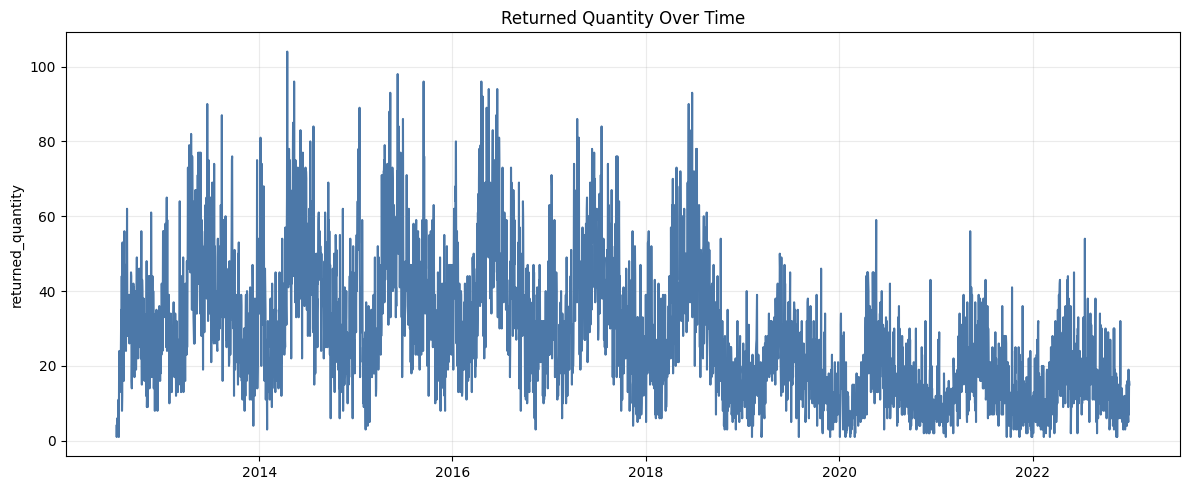

In [10]:
daily_returns = pd.DataFrame()
if returns_df.empty or returns_df['return_date_std'].isna().all():
    print('Return time series cannot be computed because return dates are unavailable.')
else:
    daily_returns = returns_df.dropna(subset=['return_date_std']).groupby('return_date_std', as_index=False).agg(
        return_count=('return_date_std', 'count'),
        returned_quantity=('returned_quantity_std', 'sum'),
        refund_amount=('refund_amount_std', 'sum'),
    ).rename(columns={'return_date_std': 'date'}).sort_values('date')
    display(daily_returns.head())
    high_qty_threshold = daily_returns['returned_quantity'].quantile(0.95)
    print('High return-quantity periods:')
    display(daily_returns[daily_returns['returned_quantity'] >= high_qty_threshold].head(20))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(daily_returns['date'], daily_returns['returned_quantity'], color='#4C78A8')
    ax.set_title('Returned Quantity Over Time')
    ax.set_ylabel('returned_quantity')
    plt.tight_layout()
    plt.show()

## 11. Refund Amount Over Time

Aggregate refund amount over time when refund data is available. If refund amount is unavailable, the notebook falls back to return quantity only.

High refund-amount periods:


,date,return_count,returned_quantity,refund_amount
85,2012-10-05,12,46,"316,901.8800"
274,2013-04-12,24,79,"336,309.8400"
277,2013-04-15,21,65,"303,525.7000"
281,2013-04-19,27,82,"370,675.1800"
293,2013-05-01,19,64,"305,624.7800"
300,2013-05-08,23,67,"324,428.2800"
306,2013-05-14,22,71,"332,492.9000"
308,2013-05-16,27,77,"334,646.0000"
313,2013-05-21,25,77,"421,315.4000"
317,2013-05-25,24,77,"303,466.9200"


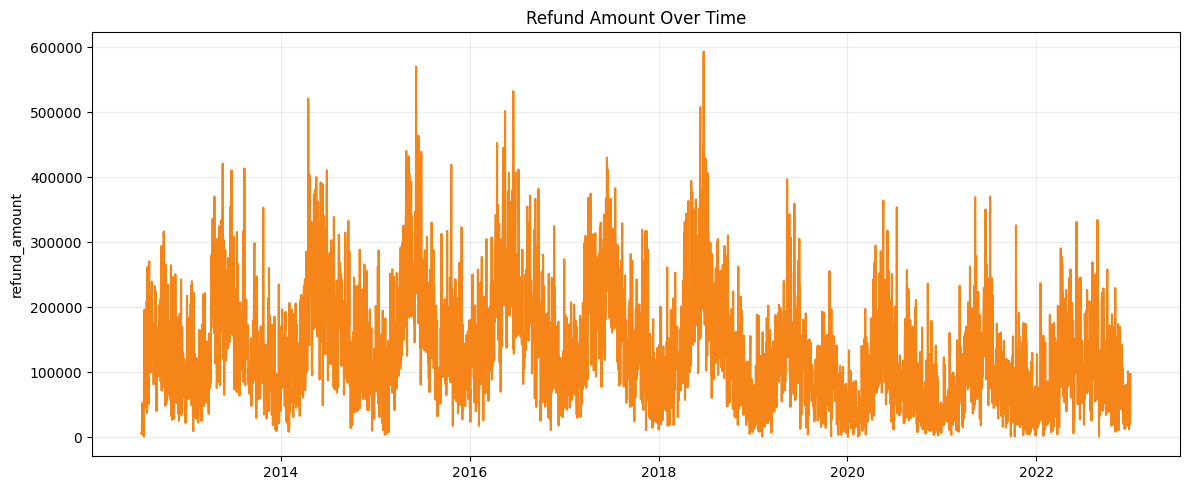

In [11]:
if daily_returns.empty or daily_returns['refund_amount'].notna().sum() == 0:
    print('Refund amount is unavailable; refund trend chart is skipped and return quantity remains the main return metric.')
else:
    high_refund_threshold = daily_returns['refund_amount'].quantile(0.95)
    print('High refund-amount periods:')
    display(daily_returns[daily_returns['refund_amount'] >= high_refund_threshold].head(20))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(daily_returns['date'], daily_returns['refund_amount'], color='#F58518')
    ax.set_title('Refund Amount Over Time')
    ax.set_ylabel('refund_amount')
    plt.tight_layout()
    plt.show()

## 12. Impact on Net Revenue

Compare gross revenue with refund-adjusted net revenue over time. Refund timing is based on return date, so this is a timing-based net-revenue view rather than a full accounting reconstruction.

,date,gross_revenue,refund_amount,returned_quantity,net_revenue,refund_to_revenue_ratio
0,2012-07-04,"5,123,547.9400",0.0000,NaN,"5,123,547.9400",0.0000
1,2012-07-05,"2,751,773.4500",0.0000,NaN,"2,751,773.4500",0.0000
2,2012-07-06,"3,054,029.4200",0.0000,NaN,"3,054,029.4200",0.0000
3,2012-07-07,"2,667,930.9400",0.0000,NaN,"2,667,930.9400",0.0000
4,2012-07-08,"2,360,851.9000",0.0000,NaN,"2,360,851.9000",0.0000
5,2012-07-09,"3,548,386.4600",0.0000,NaN,"3,548,386.4600",0.0000
6,2012-07-10,"5,234,938.6200",0.0000,NaN,"5,234,938.6200",0.0000
7,2012-07-11,"5,582,884.7800","6,493.7500",4.0000,"5,576,391.0300",0.0012
8,2012-07-12,"5,734,632.0200","4,834.0000",1.0000,"5,729,798.0200",0.0008
9,2012-07-13,"5,309,511.7100",0.0000,NaN,"5,309,511.7100",0.0000


Periods where refunds materially reduce net revenue:


,date,gross_revenue,refund_amount,returned_quantity,net_revenue,refund_to_revenue_ratio
93,2012-10-05,"2,665,953.0600","316,901.8800",46.0000,"2,349,051.1800",0.1189
101,2012-10-13,"2,798,011.4400","265,916.8000",56.0000,"2,532,094.6400",0.0950
109,2012-10-21,"2,395,609.9100","235,055.5200",31.0000,"2,160,554.3900",0.0981
121,2012-11-02,"1,936,831.0800","264,971.2100",48.0000,"1,671,859.8700",0.1368
128,2012-11-09,"2,920,310.0600","246,692.7800",44.0000,"2,673,617.2800",0.0845
183,2013-01-03,"2,281,680.0100","217,926.3300",56.0000,"2,063,753.6800",0.0955
196,2013-01-16,"1,849,789.4300","159,948.7300",52.0000,"1,689,840.7000",0.0865
197,2013-01-17,"2,173,214.9500","205,183.9300",65.0000,"1,968,031.0200",0.0944
199,2013-01-19,"2,477,132.7900","233,747.9800",59.0000,"2,243,384.8100",0.0944
241,2013-03-02,"279,813.9400","173,764.8100",26.0000,"106,049.1300",0.6210


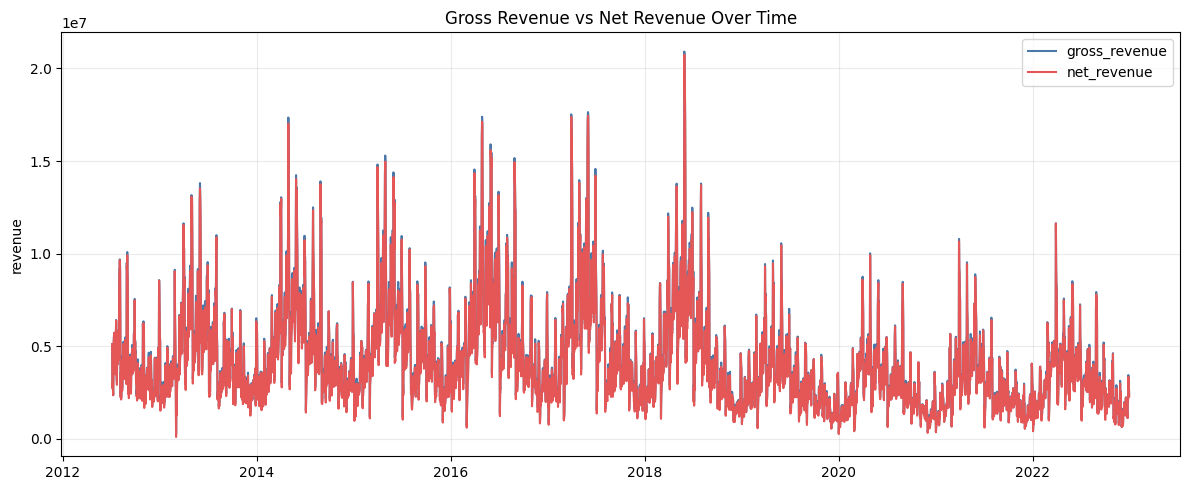

In [12]:
daily_revenue = pd.DataFrame()
daily_net_revenue = pd.DataFrame()
if sales_raw is None or sales_raw.empty or cols.get('sales_date') is None or cols.get('sales_revenue') is None:
    print('Sales data is unavailable or Revenue could not be identified; net revenue analysis cannot be computed.')
else:
    sa = sales_raw.copy()
    sa['date'] = pd.to_datetime(sa[cols['sales_date']], errors='coerce').dt.floor('D')
    sa['gross_revenue'] = to_num(sa[cols['sales_revenue']])
    daily_revenue = sa.dropna(subset=['date']).groupby('date', as_index=False)['gross_revenue'].sum(min_count=1).sort_values('date')
    if not daily_returns.empty:
        daily_net_revenue = daily_revenue.merge(daily_returns[['date', 'refund_amount', 'returned_quantity']], on='date', how='left')
    else:
        daily_net_revenue = daily_revenue.copy()
        daily_net_revenue['refund_amount'] = np.nan
        daily_net_revenue['returned_quantity'] = np.nan
    daily_net_revenue['refund_amount'] = daily_net_revenue['refund_amount'].fillna(0)
    daily_net_revenue['net_revenue'] = daily_net_revenue['gross_revenue'] - daily_net_revenue['refund_amount']
    daily_net_revenue['refund_to_revenue_ratio'] = np.where(daily_net_revenue['gross_revenue'] > 0, daily_net_revenue['refund_amount'] / daily_net_revenue['gross_revenue'], np.nan)
    display(daily_net_revenue.head(20))
    material_threshold = daily_net_revenue['refund_to_revenue_ratio'].quantile(0.95) if daily_net_revenue['refund_to_revenue_ratio'].notna().any() else np.nan
    if pd.notna(material_threshold):
        print('Periods where refunds materially reduce net revenue:')
        display(daily_net_revenue[daily_net_revenue['refund_to_revenue_ratio'] >= material_threshold].head(20))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(daily_net_revenue['date'], daily_net_revenue['gross_revenue'], label='gross_revenue', color='#4C78A8')
    ax.plot(daily_net_revenue['date'], daily_net_revenue['net_revenue'], label='net_revenue', color='#E45756')
    ax.set_title('Gross Revenue vs Net Revenue Over Time')
    ax.set_ylabel('revenue')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 13. Return Anomaly and Data Quality Checks

Inspect unmatched returns, returned quantity anomalies, refund anomalies, and time-sequence issues such as return dates before order dates.

In [13]:
anomaly_tables = {}
if items.empty:
    print('Return-enriched item data is unavailable; anomaly checks cannot be computed.')
else:
    anomaly_tables['returns_with_no_matching_order_item'] = returns_unmatched_sample.head(20) if 'returns_unmatched_sample' in globals() else pd.DataFrame()
    anomaly_tables['returned_qty_gt_ordered_qty'] = items.loc[items['returned_quantity'] > items['ordered_quantity'], ['order_id_std', 'product_id_std', 'ordered_quantity', 'returned_quantity', 'refund_amount']].head(20)
    anomaly_tables['negative_return_quantity'] = returns_df.loc[returns_df['returned_quantity_std'] < 0, ['order_id_std', 'product_id_std', 'returned_quantity_std', 'refund_amount_std']].head(20) if not returns_df.empty else pd.DataFrame()
    anomaly_tables['negative_refund_amount'] = returns_df.loc[returns_df['refund_amount_std'] < 0, ['order_id_std', 'product_id_std', 'returned_quantity_std', 'refund_amount_std']].head(20) if not returns_df.empty else pd.DataFrame()
    anomaly_tables['refund_gt_item_revenue'] = items.loc[items['refund_amount'].fillna(0) > items['item_revenue'].fillna(0), ['order_id_std', 'product_id_std', 'refund_amount', 'item_revenue']].head(20)
    anomaly_tables['missing_category_or_size'] = items.loc[items['category_final'].eq('Unknown') | items['size_final'].isna(), ['order_id_std', 'product_id_std', 'category_final', 'size_final']].head(20)
    if items['order_date_std'].notna().any() and 'first_return_date' in items.columns:
        anomaly_tables['return_before_order_date'] = items.loc[items['first_return_date'].notna() & (items['first_return_date'] < items['order_date_std']), ['order_id_std', 'product_id_std', 'order_date_std', 'first_return_date']].head(20)

    anomaly_summary = pd.DataFrame([
        {'check': name, 'count': len(df)}
        for name, df in anomaly_tables.items()
    ]).sort_values('count', ascending=False)
    display(anomaly_summary)
    for name, df in anomaly_tables.items():
        if not df.empty:
            print(f'Example records: {name}')
            display(df)

,check,count
1,returned_qty_gt_ordered_qty,3
4,refund_gt_item_revenue,3
0,returns_with_no_matching_order_item,0
2,negative_return_quantity,0
3,negative_refund_amount,0
5,missing_category_or_size,0
6,return_before_order_date,0


Example records: returned_qty_gt_ordered_qty


,order_id_std,product_id_std,ordered_quantity,returned_quantity,refund_amount
347486,397622,2045,8,11.0000,"57,690.9700"
347487,397622,2045,6,11.0000,"57,690.9700"
602445,698128,1009,1,4.0000,"4,122.0700"


Example records: refund_gt_item_revenue


,order_id_std,product_id_std,refund_amount,item_revenue
347486,397622,2045,"57,690.9700","45,076.1600"
347487,397622,2045,"57,690.9700","33,501.7200"
602445,698128,1009,"4,122.0700","1,093.4500"


## 14. Leakage-Safe Return Forecast Feature Preview

Create historical return/refund features using lagged daily values only. Future returns and refunds are not used directly.

In [14]:
feature_preview = pd.DataFrame()
feature_registry = pd.DataFrame()
if daily_net_revenue.empty:
    print('Daily revenue and refund data are unavailable; return feature preview cannot be built.')
else:
    feature_preview = daily_net_revenue.sort_values('date').copy()
    feature_preview['return_rate'] = np.where(feature_preview['gross_revenue'] > 0, feature_preview['refund_amount'] / feature_preview['gross_revenue'], np.nan)
    feature_preview['return_rate_lag_30'] = feature_preview['return_rate'].shift(30)
    feature_preview['refund_amount_lag_30'] = feature_preview['refund_amount'].shift(30)
    feature_preview['return_quantity_lag_30'] = feature_preview['returned_quantity'].shift(30)
    feature_preview['refund_to_revenue_ratio_lag_30'] = feature_preview['refund_to_revenue_ratio'].shift(30)
    feature_preview['return_rate_roll_mean_30'] = feature_preview['return_rate'].shift(1).rolling(30, min_periods=7).mean()
    feature_preview['refund_amount_roll_mean_30'] = feature_preview['refund_amount'].shift(1).rolling(30, min_periods=7).mean()

    if not items.empty and 'category_final' in items.columns and items['category_final'].nunique() > 0 and items['order_date_std'].notna().any():
        cat_daily = items.groupby(['order_date_std', 'category_final']).agg(
            ordered_quantity=('ordered_quantity', 'sum'),
            returned_quantity=('returned_quantity', 'sum'),
        ).reset_index()
        cat_daily['category_return_rate'] = np.where(cat_daily['ordered_quantity'] > 0, cat_daily['returned_quantity'] / cat_daily['ordered_quantity'], np.nan)
        cat_pressure = cat_daily.groupby('order_date_std')['category_return_rate'].max().reset_index(name='category_return_pressure')
        cat_pressure = cat_pressure.rename(columns={'order_date_std': 'date'}).sort_values('date')
        cat_pressure['category_return_pressure_lag_30'] = cat_pressure['category_return_pressure'].shift(30)
        feature_preview = feature_preview.merge(cat_pressure[['date', 'category_return_pressure_lag_30']], on='date', how='left')

    preview_cols = ['date', 'gross_revenue', 'refund_amount', 'net_revenue', 'returned_quantity', 'return_rate', 'return_rate_lag_30', 'refund_amount_lag_30', 'return_quantity_lag_30', 'refund_to_revenue_ratio_lag_30', 'return_rate_roll_mean_30', 'refund_amount_roll_mean_30']
    if 'category_return_pressure_lag_30' in feature_preview.columns:
        preview_cols.append('category_return_pressure_lag_30')
    display(feature_preview[preview_cols].head(40))

    same_day_known_only = ['refund_amount', 'returned_quantity', 'return_rate', 'refund_to_revenue_ratio']
    historical_safe = [c for c in feature_preview.columns if c.endswith('_lag_30') or c.endswith('_mean_30')]
    feature_registry = pd.DataFrame({
        'feature': same_day_known_only + historical_safe,
        'feature_type': ['requires known current-day returns/refunds'] * len(same_day_known_only) + ['historical lagged/rolling only'] * len(historical_safe),
        'forecast_use_note': ['Use only if current-day return/refund information is genuinely known before prediction.'] * len(same_day_known_only) + ['Leakage-safe because the feature uses only prior realized return history.'] * len(historical_safe),
    })
    display(feature_registry)

,date,gross_revenue,refund_amount,net_revenue,returned_quantity,return_rate,return_rate_lag_30,refund_amount_lag_30,return_quantity_lag_30,refund_to_revenue_ratio_lag_30,return_rate_roll_mean_30,refund_amount_roll_mean_30,category_return_pressure_lag_30
0,2012-07-04,"5,123,547.9400",0.0000,"5,123,547.9400",NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",0.0000,"2,751,773.4500",NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",0.0000,"3,054,029.4200",NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",0.0000,"2,667,930.9400",NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",0.0000,"2,360,851.9000",NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",0.0000,"3,548,386.4600",NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",0.0000,"5,234,938.6200",NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800","6,493.7500","5,576,391.0300",4.0000,0.0012,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN
8,2012-07-12,"5,734,632.0200","4,834.0000","5,729,798.0200",1.0000,0.0008,NaN,NaN,NaN,NaN,0.0001,811.7188,NaN
9,2012-07-13,"5,309,511.7100",0.0000,"5,309,511.7100",NaN,0.0000,NaN,NaN,NaN,NaN,0.0002,"1,258.6389",NaN


,feature,feature_type,forecast_use_note
0,refund_amount,requires known current-day returns/refunds,Use only if current-day return/refund informat...
1,returned_quantity,requires known current-day returns/refunds,Use only if current-day return/refund informat...
2,return_rate,requires known current-day returns/refunds,Use only if current-day return/refund informat...
3,refund_to_revenue_ratio,requires known current-day returns/refunds,Use only if current-day return/refund informat...
4,return_rate_lag_30,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
5,refund_amount_lag_30,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
6,return_quantity_lag_30,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
7,refund_to_revenue_ratio_lag_30,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
8,return_rate_roll_mean_30,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
9,refund_amount_roll_mean_30,historical lagged/rolling only,Leakage-safe because the feature uses only pri...


## 15. Key Observations and Warnings

Final concise summary with high-return categories/sizes, high-return periods, net-revenue impact, anomaly warnings, and leakage-safe forecast features.

In [15]:
def fmt(x, digits=4):
    return 'n/a' if pd.isna(x) else f'{x:,.{digits}f}'

summary_lines = []

if not category_return.empty:
    top_cat = category_return.head(5)
    summary_lines.append('Categories with the highest return rate: ' + ', '.join(f"{r.category_final} ({r.return_rate:.2%})" for r in top_cat.itertuples()))
else:
    summary_lines.append('Category return rates could not be computed.')

if not size_return.empty:
    top_size = size_return.head(5)
    summary_lines.append('Sizes with the highest return rate: ' + ', '.join(f"{r.size_final} ({r.return_rate:.2%})" for r in top_size.itertuples()))
else:
    summary_lines.append('Return-rate-by-size analysis could not be performed because size data was unavailable.')

if not heatmap_matrix.empty:
    mat_long = heatmap_matrix.stack().reset_index(name='return_rate').sort_values('return_rate', ascending=False).head(5)
    summary_lines.append('Category-size combinations with high return risk: ' + ', '.join(f"{r.category_final}/{r.size_final} ({r.return_rate:.2%})" for r in mat_long.itertuples()))

if not daily_returns.empty:
    high_qty = daily_returns.sort_values('returned_quantity', ascending=False).head(5)
    summary_lines.append('Periods with high return quantity: ' + ', '.join(f"{pd.Timestamp(r.date).date()} ({r.returned_quantity:,.0f})" for r in high_qty.itertuples()))
    if daily_returns['refund_amount'].notna().sum() > 0:
        high_refund = daily_returns.sort_values('refund_amount', ascending=False).head(5)
        summary_lines.append('Periods with high refund amount: ' + ', '.join(f"{pd.Timestamp(r.date).date()} ({r.refund_amount:,.2f})" for r in high_refund.itertuples()))

if not daily_net_revenue.empty and daily_net_revenue['refund_to_revenue_ratio'].notna().any():
    ratio = daily_net_revenue['refund_to_revenue_ratio']
    impact = 'material' if ratio.quantile(0.95) >= 0.05 else 'limited'
    summary_lines.append(f'Returns appear to reduce net revenue {impact} under the observed refund-to-revenue distribution; 95th percentile ratio is {ratio.quantile(0.95):.2%}.')
else:
    summary_lines.append('Net-revenue impact could not be fully evaluated because refund or revenue timing data was unavailable.')

if return_warnings:
    summary_lines.append('Return data quality warnings: ' + '; '.join(return_warnings))
else:
    summary_lines.append('Return data quality warnings: none beyond the checks reported in the notebook tables.')

summary_lines.append('Recommended leakage-safe return/refund forecast features: return_rate_lag_30, refund_amount_lag_30, return_quantity_lag_30, refund_to_revenue_ratio_lag_30, return_rate_roll_mean_30, refund_amount_roll_mean_30, and category_return_pressure_lag_30.')
summary_lines.append('Future return and refund values must not be used directly unless they are genuinely known before prediction.')
summary_lines.append('Causal caution: this is observational EDA. Returns and net revenue can move together because of product quality, sizing, logistics, promotions, and customer mix.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Categories with the highest return rate: GenZ (3.52%), Outdoor (3.45%), Streetwear (3.38%), Casual (3.26%)
- Sizes with the highest return rate: S (3.46%), L (3.43%), M (3.40%), XL (3.36%)
- Category-size combinations with high return risk: GenZ/XL (3.77%), GenZ/S (3.61%), GenZ/M (3.59%), Outdoor/S (3.55%), Outdoor/L (3.52%)
- Periods with high return quantity: 2014-04-17 (104), 2015-06-08 (98), 2016-04-19 (96), 2014-05-13 (96), 2015-09-14 (96)
- Periods with high refund amount: 2018-06-24 (593,465.02), 2015-06-08 (570,647.81), 2016-06-18 (532,795.58), 2014-04-17 (521,279.22), 2018-06-11 (508,136.51)
- Returns appear to reduce net revenue material under the observed refund-to-revenue distribution; 95th percentile ratio is 8.34%.
- Return data quality warnings: none beyond the checks reported in the notebook tables.
- Recommended leakage-safe return/refund forecast features: return_rate_lag_30, refund_amount_lag_30, return_quantity_lag_30, refund_to_reven